# Monte Carlo Markov Chain: Metropolis Hasting

### Pirmer ejercicio con datos datos artificiales

In [32]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['axes.axisbelow'] = True       ## Fijar parámetros de plots
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [33]:
## Definimos el modelo
def recta(x,theta):
    return x*theta[0] + theta[1]

## Verificamos que la propuesta está dentro de los límites
def logPrior(theta,bounds):
    #m,b = theta
    count = 0.0
    for param, lim in zip(theta, bounds):
        if lim[0] < param < lim[1]:
            continue
        else:
            count += -np.inf
    return count

## Calculamos el likelihood
def logLikelihood(theta,x,y,yerr):
    y_model = recta(x,theta)
    chi2 = np.sum((y-y_model)**2/(2*yerr**2))
    return -chi2

## Calculamos la probabilidad (Prior y likelihood)
def logPosterior(theta,x,y,yerr,bounds):
    lp = logPrior(theta,bounds)
    if not np.isfinite(lp):
        return -np.inf
    return lp + logLikelihood(theta,x,y,yerr)

## Generamos propuestas condistribución gaussianas centradas en el punto
def proposal(theta,sigma):
    prop = []
    for param, s in zip(theta, sigma):
        new = np.random.normal(param,s)
        prop.append(new)
    #m_new = np.random.normal(theta[0],sigma[0])
    #b_new = np.random.normal(theta[1],sigma[1])
    #return np.array([m_new,b_new])
    return np.array(prop)

In [34]:
# Información de los datos: valores reales y datos
np.random.seed(0)              ## Obtenemos los mismos valores siempre
m_true = -2.7
b_true = 4.3
N = 100
x = np.linspace(0,10,N)
y_true = m_true*x + b_true
yerr = 0.3*np.ones(N)
noise = np.random.normal(0,yerr,size=N)
y = y_true + noise

In [35]:
bounds = [[-10,10],[-10,10]]
theta = np.array([-2.5,4.5])
sigma_prop = [0.01,0.03]
n_iter = 10000
chain = []
logP = logPosterior(theta,x,y,yerr,bounds)
for i in range(n_iter):
    theta_prop = proposal(theta,sigma_prop)
    #print(theta_prop)
    logP_prop = logPosterior(theta_prop,x,y,yerr,bounds)
    accept_ratio = logP_prop - logP
    if accept_ratio > 0:
        theta = theta_prop
        logP = logP_prop
        chain.append(theta)
    else:
        random = np.random.uniform()
        if np.log(random) < accept_ratio:
            theta = theta_prop
            logP = logP_prop
            chain.append(theta)

In [36]:
chain = np.array(chain)

True values are: m = -2.7, b = 4.3
Last values in chain are: m = [-2.70179936] and b = [4.36757104]


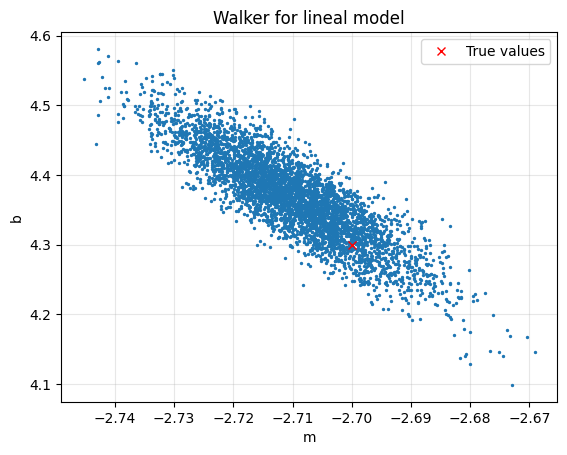

In [37]:
print("True values are: m = -2.7, b = 4.3")
print(f"Last values in chain are: m = " + str(chain[-1:,0]) + f" and b = " + str(chain[-1:,1]))

plt.scatter(chain[100:,0],chain[100:,1],s=2)

plt.plot(m_true,b_true,'rx', label = f'True values')
plt.title('Walker for lineal model')

plt.xlabel('m')
plt.ylabel('b')

plt.legend()
plt.show()

### Segundo ejericico: obtener el sjuate para dos listas de datos

In [38]:
data1 =np.loadtxt("line-1.dat")
data2 =np.loadtxt("line-2.dat")

In [39]:
x1 = data1[0]
y1 = data1[1]
yerr1 = data1[2]

def logLikelihood(theta,x,y,yerr):
    y_model = recta(x,theta)
    chi2 = np.sum((y-y_model)**2/(2*yerr**2))
    return -chi2

In [40]:
bounds = [[-10,10],[-10,10]]
theta = np.array([-2.5,4.5])
sigma_prop = [0.01,0.03]
n_iter = 100000
chain = []
logP = logPosterior(theta,x1,y1,yerr1,bounds)
for i in range(n_iter):
    theta_prop = proposal(theta,sigma_prop)
    logP_prop = logPosterior(theta_prop,x1,y1,yerr1,bounds)
    accept_ratio = logP_prop - logP
    if accept_ratio > 0:
        theta = theta_prop
        logP = logP_prop
        chain.append(theta)
    else:
        random = np.random.uniform()
        if np.log(random) < accept_ratio:
            theta = theta_prop
            logP = logP_prop
            chain.append(theta)

In [41]:
chain = np.array(chain)

no_burn = chain[1000:]          ## Quitamos los primeros pasos del caminante
m_med = np.median(no_burn[:,0])
b_med = np.median(no_burn[:,1])

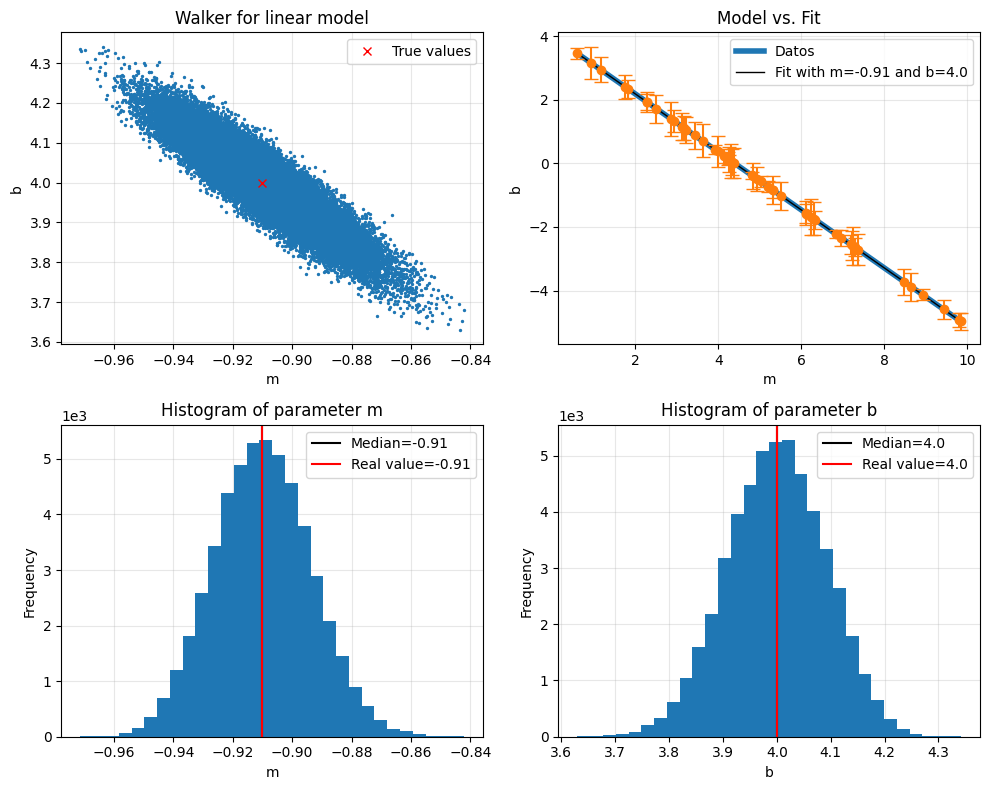

In [42]:
m_real = -0.91
b_real = 4.0
y_real = m_real*x1 + b_real
fig, axs = plt.subplots(2, 2, figsize=(10,8))

# Plot 1
axs[0,0].scatter(chain[1000:,0],chain[1000:,1],s=2)
axs[0,0].set_xlabel("m")
axs[0,0].set_ylabel("b")
axs[0,0].plot(m_real,b_real,'rx', label = f'True values')
axs[0,0].set_title("Walker for linear model")
axs[0,0].legend()


# Plot 2
axs[0,1].plot(x1,y_real, lw=4, label = f'Datos')
axs[0,1].plot(x1,m_med*x1 + b_med, 
              color='k',
              lw=1, 
              label = 'Fit with m='+str(np.round(m_med, 2))+' and b='+str(np.round(b_med, 2)))
axs[0,1].errorbar(x1, y1,yerr=yerr1,fmt='o',capsize=5)
axs[0,1].set_xlabel("m")
axs[0,1].set_ylabel("b")
axs[0,1].set_title("Model vs. Fit")
axs[0,1].legend()

# Plot 3
axs[1,0].hist(no_burn[:,0], bins = 30)
axs[1,0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axs[1,0].axvline(x = m_med, color ='black', label ='Median='+ str(np.round(m_med, 2)))
axs[1,0].axvline(x = m_real, color ='red', label ='Real value='+ str(np.round(m_real, 2)))
axs[1,0].set_xlabel("m")
axs[1,0].set_ylabel("Frequency")
axs[1,0].set_title("Histogram of parameter m")
axs[1,0].legend()

# Plot 4
axs[1,1].hist(no_burn[:,1], bins = 30)
axs[1,1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axs[1,1].axvline(x= b_med, color ='black', label ='Median='+ str(np.round(b_med, 2)))
axs[1,1].axvline(x = b_real, color ='red', label ='Real value='+ str(np.round(b_real, 2)))
axs[1,1].set_xlabel("b")
axs[1,1].set_ylabel("Frequency")
axs[1,1].set_title("Histogram of parameter b")
axs[1,1].legend()

plt.tight_layout()
plt.show()

In [43]:
x2 = data2[0]
y2 = data2[1]
yerr2 = data2[2]

In [44]:
bounds = [[-10,10],[-10,10]]
theta = np.array([-2.5,4.5])
sigma_prop = [0.01,0.03]
n_iter = 100000
chain = []
logP = logPosterior(theta,x2,y2,yerr2,bounds)
for i in range(n_iter):
    theta_prop = proposal(theta,sigma_prop)
    logP_prop = logPosterior(theta_prop,x2,y2,yerr2,bounds)
    accept_ratio = logP_prop - logP
    if accept_ratio > 0:
        theta = theta_prop
        logP = logP_prop
        chain.append(theta)
    else:
        random = np.random.uniform()
        if np.log(random) < accept_ratio:
            theta = theta_prop
            logP = logP_prop
            chain.append(theta)

In [45]:
chain = np.array(chain)

no_burn = chain[1000:]          ## Quitamos los primeros pasos del caminante
m_med = np.median(no_burn[:,0])
b_med = np.median(no_burn[:,1])

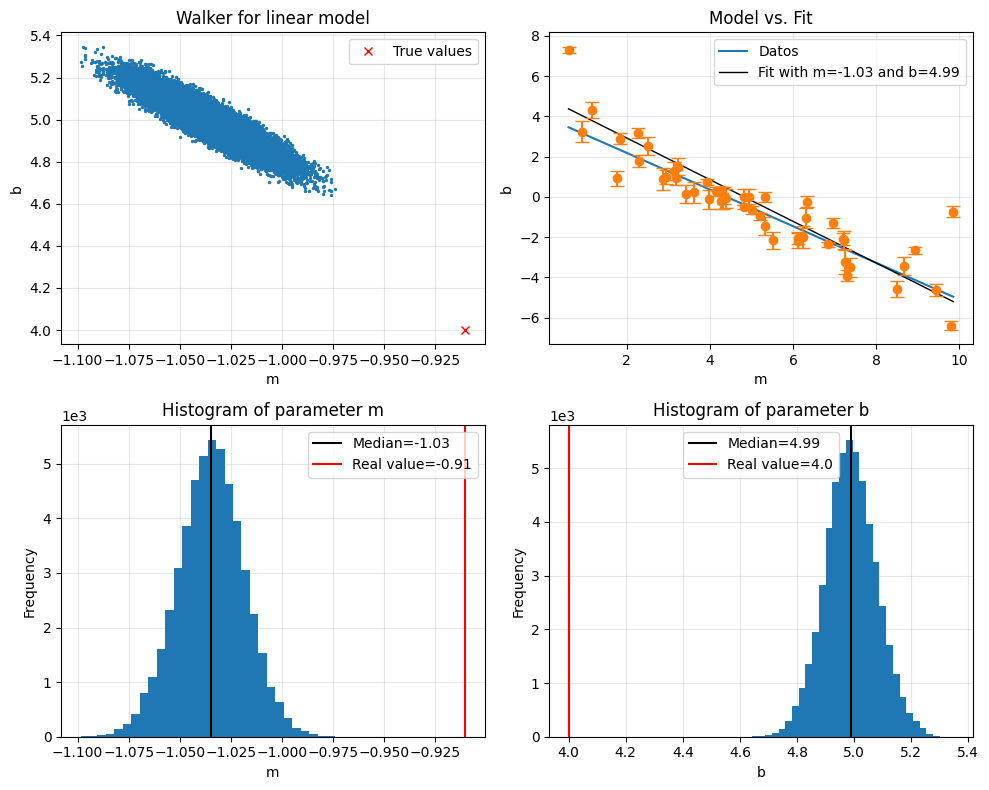

In [46]:
y_real = m_real*x2 + b_real
fig, axs = plt.subplots(2, 2, figsize=(10,8))

# Plot 1
axs[0,0].scatter(chain[1000:,0],chain[1000:,1],s=2)
axs[0,0].set_xlabel("m")
axs[0,0].set_ylabel("b")
axs[0,0].plot(m_real,b_real,'rx', label = f'True values')
axs[0,0].set_title("Walker for linear model")
axs[0,0].legend()


# Plot 2
axs[0,1].plot(x2,y_real, label = f'Datos')
axs[0,1].plot(x2,m_med*x2 + b_med, 
              color='k',
              lw=1, 
              label = 'Fit with m='+str(np.round(m_med, 2))+' and b='+str(np.round(b_med, 2)))
axs[0,1].errorbar(x2, y2,yerr=yerr2,fmt='o',capsize=5)
axs[0,1].set_xlabel("m")
axs[0,1].set_ylabel("b")
axs[0,1].set_title("Model vs. Fit")
axs[0,1].legend()

# Plot 3
axs[1,0].hist(no_burn[:,0], bins = 30)
axs[1,0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axs[1,0].axvline(x = m_med, color ='black', label ='Median='+ str(np.round(m_med, 2)))
axs[1,0].axvline(x = m_real, color ='red', label ='Real value='+ str(np.round(m_real, 2)))
axs[1,0].set_xlabel("m")
axs[1,0].set_ylabel("Frequency")
axs[1,0].set_title("Histogram of parameter m")
axs[1,0].legend()

# Plot 4
axs[1,1].hist(no_burn[:,1], bins = 30)
axs[1,1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axs[1,1].axvline(x= b_med, color ='black', label ='Median='+ str(np.round(b_med, 2)))
axs[1,1].axvline(x = b_real, color ='red', label ='Real value='+ str(np.round(b_real, 2)))
axs[1,1].set_xlabel("b")
axs[1,1].set_ylabel("Frequency")
axs[1,1].set_title("Histogram of parameter b")
axs[1,1].legend()

plt.tight_layout()
plt.show()

Conclución: la dispersión en los datos altera más el resultado que la presición (qué tan grandes son las barras de error) en las mediciones.

### Más de un caminador

In [47]:
bounds = [[-10,10],[-10,10]]
theta1 = [np.array([-2.5,4.5]), np.array([0,0]), np.array([-1,-1])]
sigma_prop = [0.01,0.03]
n_iter = 100000
chains = []                                          ## Agregamos una lista sonde se guardaran los caminadores
yerr = 0.3*np.ones(len(x1))
for theta in theta1:                                 ## Ciclo que se repite n veces donde n es la longitud de los 'guess',
    chain = []                                        # el número de caminadores dependerá de el número de posiciones inciales
    logP = logPosterior(theta,x1,y1,yerr1,bounds)
    for i in range(n_iter):
        theta_prop = proposal(theta,sigma_prop)
        logP_prop = logPosterior(theta_prop,x1,y1,yerr1,bounds)
        accept_ratio = logP_prop - logP
        if accept_ratio > 0:
            theta = theta_prop
            logP = logP_prop
            chain.append(theta)
        else:
            random = np.random.uniform()
            if np.log(random) < accept_ratio:
                theta = theta_prop
                logP = logP_prop
                chain.append(theta)
    chains.append(chain)

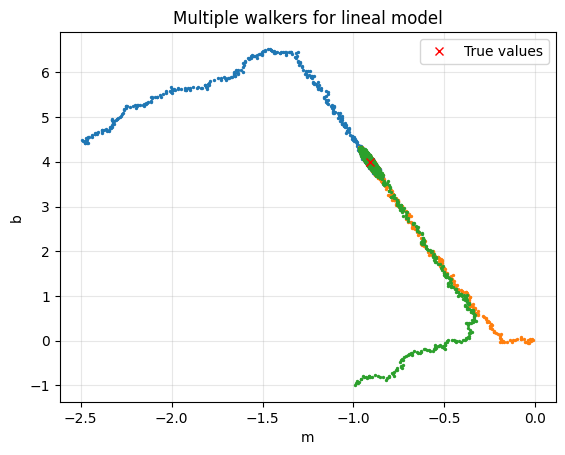

In [48]:
for c in chains:
    plt.scatter(np.array(c)[:,0],np.array(c)[:,1],s=2)

plt.plot(m_real,b_real,'rx', label = f'True values')
plt.title('Multiple walkers for lineal model')

plt.xlabel('m')
plt.ylabel('b')

plt.legend()
plt.show()

### Agregar error cuadrático
#### Agregamos un término $f^2(mx + b)^2$ al error, donde $f$ es un nuevo parámetro libre 

En ese caso, como el error depende del modelo, no podemos ignorar la normalización en el likelihood:
\begin{equation}
P = \Pi_i \left[ \textcolor{red}{\frac{1}{2 \pi \sigma^2_i}} \exp \left(- \frac{(y_i - y_{modelo})^2}{2 \sigma^2_i} \right) \right]
\end{equation}

con $P$ el posterior. Sacando el logaritmo:
\begin{equation}
\ln P = -\sum \left[ \ln \left(2 \pi \sigma^2_i \right) + \frac{(y_i - y_{modelo})^2}{2 \sigma^2_i} \right]
\end{equation}
y se sigue cumpliendo 

In [49]:
## Calculamos el likelihood
def logLikelihood(theta, x, y, yerr):
    y_model = recta(x, theta)
    sigma2 = 2*(yerr**2 + (theta[2]*y_model)**2)
    chi2 = np.sum((y - y_model)**2 / sigma2 + np.log(2*np.pi*sigma2))
    return -chi2

In [50]:
x1 = data1[0]
y1 = data1[1]
yerr1 = data1[2]

In [51]:
bounds = [[-10,10],[-10,10],[0, 10]]
theta = np.array([-2.5,4.5, 1])
sigma_prop = [0.01,0.03,0.01]
n_iter = 1000000
chain = []
logP = logPosterior(theta,x1,y1,yerr1,bounds)
for i in range(n_iter):
    theta_prop = proposal(theta,sigma_prop)
    logP_prop = logPosterior(theta_prop,x1,y1,yerr1,bounds)
    accept_ratio = logP_prop - logP
    if accept_ratio > 0:
        theta = theta_prop
        logP = logP_prop
        chain.append(theta)
    else:
        random = np.random.uniform()
        if np.log(random) < accept_ratio:
            theta = theta_prop
            logP = logP_prop
            chain.append(theta)

True values are: m = -0.91, b = 4.0
Last values in chain are: m = [-0.90893515], b = [3.9501484] and f = [0.01442806]


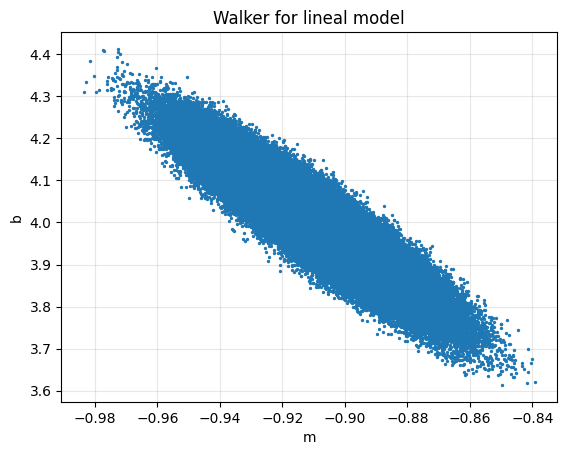

In [52]:
no_burn = np.array(chain[10000:])
print("True values are: m = -0.91, b = 4.0")
print(f"Last values in chain are: m = " + str(no_burn[-1:,0]) 
      + f", b = " + str(no_burn[-1:,1]) 
      + f" and f = " + str(no_burn[-1:,2]))

plt.scatter(no_burn[:,0], no_burn[:,1],s=2)

#plt.plot(m_real,b_real,'rx', label = f'True values')
plt.title('Walker for lineal model')

plt.xlabel('m')
plt.ylabel('b')

#plt.legend()
plt.show()

In [53]:
import corner

In [54]:
labels = ['m', 'b', 'log f']
samples = np.array([no_burn[:,0], no_burn[:,1], no_burn[:,2]]).T
print(samples.shape)

(348299, 3)


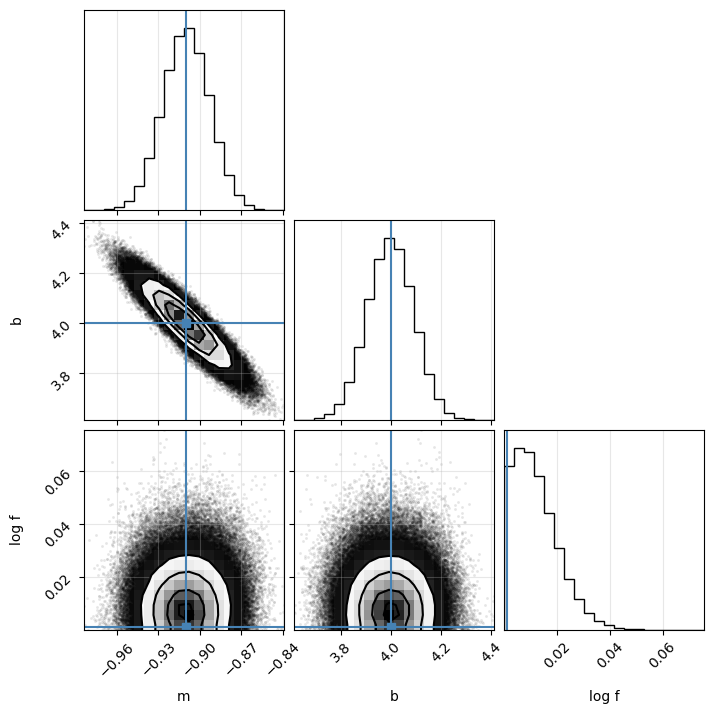

In [55]:
f_median = np.median(no_burn[:,2])
figure = corner.corner(samples, labels = labels, truths=[m_real, b_real, 0.001])

## Agregar más caminadores??